# 🔧 Notebook 02 — Preprocessing Pipeline
### Quality-Aware FER Project

**Dataset:** `dataset/train` `dataset/validation` `dataset/test`
**Format:** PNG/JPG gambar wajah real (bukan pixel string)

**Perubahan v2:**
- Proses **semua** gambar (bukan hanya 100 sampel)
- Tambah CLAHE equalization untuk meningkatkan kontras wajah
- Tampilkan statistik per split per kelas

In [1]:
import sys, cv2, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm import tqdm

# Temukan ROOT project secara robust
current_path = Path(".").resolve()
if (current_path / "src").exists() and (current_path / "configs").exists():
    ROOT = current_path
elif (current_path.parent / "src").exists() and (current_path.parent / "configs").exists():
    ROOT = current_path.parent
else:
    ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))
plt.style.use("dark_background")

DATASET_ROOT = ROOT / "dataset"
OUTPUT_DIR   = ROOT / "data" / "processed"
SAVE_DIR     = ROOT / "results" / "plots" / "eda"
SAVE_DIR.mkdir(parents=True, exist_ok=True)
IMG_SIZE     = 224

EMOTION_CLASSES = ["angry","contempt","disgust","fear","happy","neutral","sad","suprise"]
SPLITS_MAP      = {"train":"train","validation":"val","test":"test"}
COLORS          = ["#ef4444","#a16207","#a855f7","#f97316","#22c55e","#94a3b8","#3b82f6","#eab308"]
CMAP            = dict(zip(EMOTION_CLASSES, COLORS))

print(f"✅ Dataset root : {DATASET_ROOT}")
print(f"✅ Output root  : {OUTPUT_DIR}")

# ── Scan dataset ─────────────────────────────────────────────────────────────
records = []
for split in ["train","validation","test"]:
    split_dir = DATASET_ROOT / split
    if not split_dir.exists(): continue
    for cls_dir in sorted(split_dir.iterdir()):
        if not cls_dir.is_dir(): continue
        for p in list(cls_dir.glob("*.png")) + list(cls_dir.glob("*.jpg")):
            records.append({"path":str(p),"emotion":cls_dir.name.lower(),"split":split})

df       = pd.DataFrame(records)
train_df = df[df["split"]=="train"].reset_index(drop=True)
val_df   = df[df["split"]=="validation"].reset_index(drop=True)
test_df  = df[df["split"]=="test"].reset_index(drop=True)

print(f"\n📊 Dataset Summary:")
print(f"   Train      : {len(train_df):,} gambar")
print(f"   Validation : {len(val_df):,} gambar")
print(f"   Test       : {len(test_df):,} gambar")
print(f"   Total      : {len(df):,} gambar")

✅ Dataset root : D:\BIG-Data\tuber\dataset
✅ Output root  : D:\BIG-Data\tuber\data\processed

📊 Dataset Summary:
   Train      : 64,000 gambar
   Validation : 8,341 gambar
   Test       : 3,573 gambar
   Total      : 75,914 gambar


## 1. Distribusi Per-Kelas Per-Split

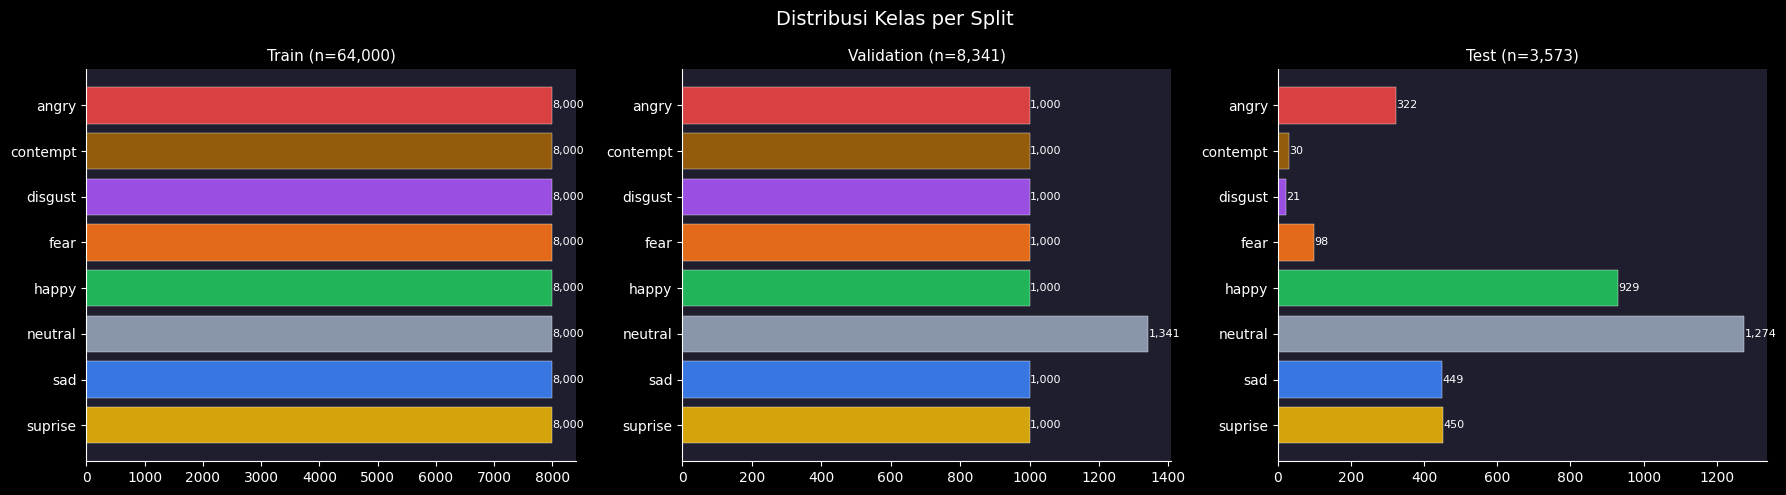


Kelas            Train       Val      Test
----------------------------------------
angry            8,000     1,000       322
contempt         8,000     1,000        30
disgust          8,000     1,000        21
fear             8,000     1,000        98
happy            8,000     1,000       929
neutral          8,000     1,341     1,274
sad              8,000     1,000       449
suprise          8,000     1,000       450


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Distribusi Kelas per Split", fontsize=14, color="white")

for ax, (split_name, split_df) in zip(axes, [
    ("Train", train_df), ("Validation", val_df), ("Test", test_df)
]):
    counts = split_df["emotion"].value_counts().reindex(EMOTION_CLASSES, fill_value=0)
    bars   = ax.barh(counts.index[::-1], counts.values[::-1],
                     color=COLORS[::-1], edgecolor="white", linewidth=0.3, alpha=0.9)
    for bar in bars:
        ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
                f"{int(bar.get_width()):,}", va="center", ha="left", color="white", fontsize=8)
    ax.set_title(f"{split_name} (n={len(split_df):,})", color="white", fontsize=11)
    ax.set_facecolor("#1e1e2e"); ax.tick_params(colors="white")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(SAVE_DIR/"preprocessing_00_class_dist.png", dpi=120, bbox_inches="tight", facecolor="#0f1117")
plt.show()

# Print tabel per kelas
print(f"\n{'Kelas':<12}", end="")
for s in ["Train","Val","Test"]:
    print(f"  {s:>8}", end="")
print()
print("-" * 40)
for emo in EMOTION_CLASSES:
    train_c = len(train_df[train_df["emotion"]==emo])
    val_c   = len(val_df[val_df["emotion"]==emo])
    test_c  = len(test_df[test_df["emotion"]==emo])
    print(f"{emo:<12}  {train_c:>8,}  {val_c:>8,}  {test_c:>8,}")

## 2. Sample Gambar Asli dari Dataset

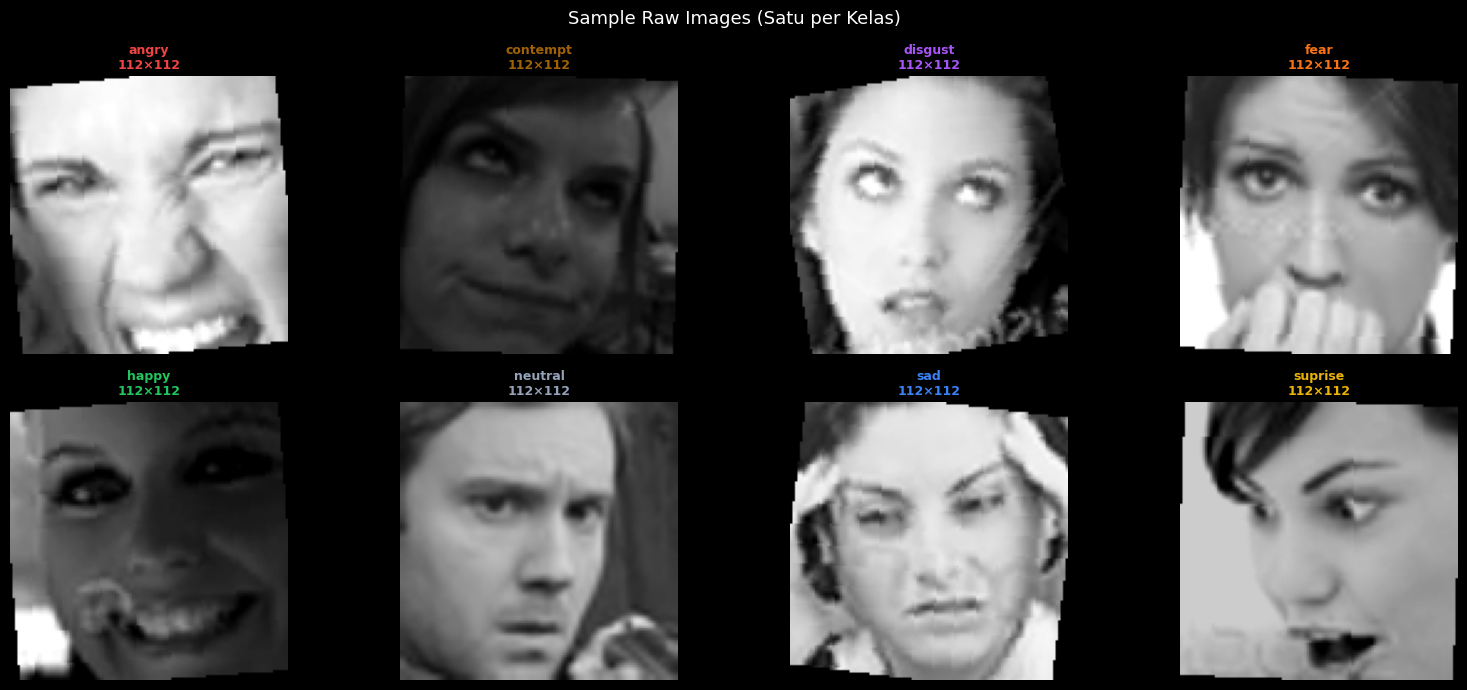

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle("Sample Raw Images (Satu per Kelas)", fontsize=13, color="white")

for i, emo in enumerate(EMOTION_CLASSES):
    ax = axes[i//4][i%4]
    subset = train_df[train_df["emotion"]==emo]
    if len(subset) == 0:
        ax.imshow(np.zeros((224,224,3), np.uint8))
        ax.set_title(f"{emo}\n(0 samples)", color="red", fontsize=9)
        ax.axis("off"); continue

    img = cv2.imread(subset.iloc[0]["path"])
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(f"{emo}\n{img.shape[1]}×{img.shape[0]}", color=COLORS[i], fontsize=9, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.savefig(SAVE_DIR/"preprocessing_01_raw_samples.png", dpi=120, bbox_inches="tight", facecolor="#0f1117")
plt.show()

## 3. Pipeline Preprocessing Step-by-Step (dengan CLAHE)

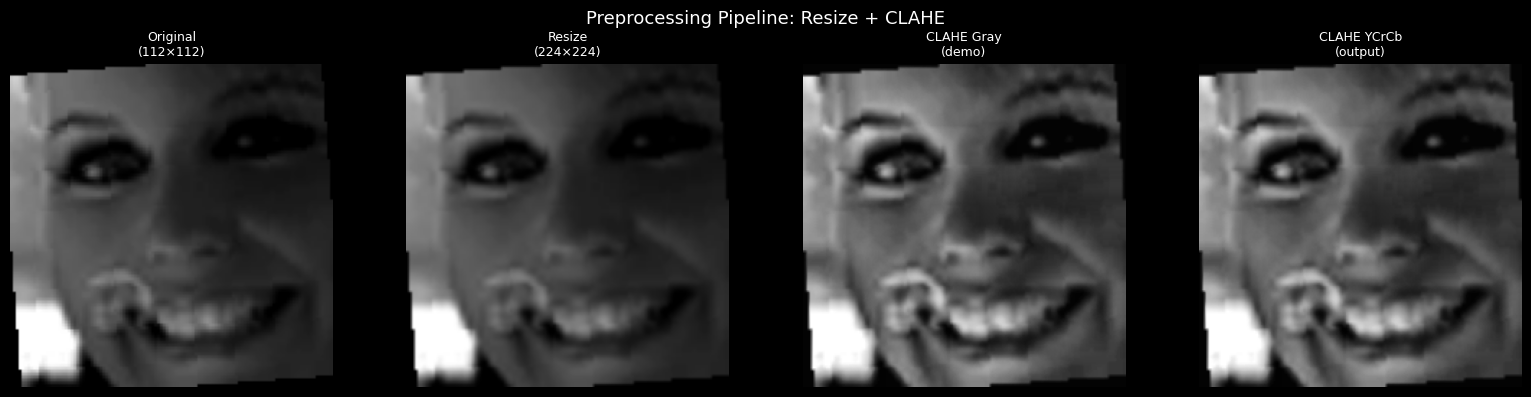

In [4]:
# Ambil satu sampel untuk demonstrasi
sample_path = train_df[train_df["emotion"]=="happy"].iloc[0]["path"]
img_bgr     = cv2.imread(sample_path)
h0, w0      = img_bgr.shape[:2]

# Pipeline: Original → Resize → CLAHE → Final (resize + CLAHE)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

img_resized = cv2.resize(img_bgr, (224,224))
img_gray_r  = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
img_clahe   = clahe.apply(img_gray_r)
img_clahe_3 = cv2.cvtColor(img_clahe, cv2.COLOR_GRAY2BGR)   # hanya demo

# CLAHE per channel (yang sebenarnya kita simpan dalam RGB)
img_ycrcb   = cv2.cvtColor(img_resized, cv2.COLOR_BGR2YCrCb)
img_ycrcb[:,:,0] = clahe.apply(img_ycrcb[:,:,0])
img_clahe_rgb    = cv2.cvtColor(
    cv2.cvtColor(img_ycrcb, cv2.COLOR_YCrCb2BGR), cv2.COLOR_BGR2RGB
)

steps = {
    f"Original\n({w0}×{h0})":    cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB),
    "Resize\n(224×224)":          cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB),
    "CLAHE Gray\n(demo)":         cv2.cvtColor(img_clahe_3, cv2.COLOR_BGR2RGB),
    "CLAHE YCrCb\n(output)":      img_clahe_rgb,
}

fig, axes = plt.subplots(1, len(steps), figsize=(16, 4))
fig.suptitle("Preprocessing Pipeline: Resize + CLAHE", fontsize=13, color="white")
for i, (title, img) in enumerate(steps.items()):
    axes[i].imshow(img)
    axes[i].set_title(title, color="white", fontsize=9)
    axes[i].axis("off")
plt.tight_layout()
plt.savefig(SAVE_DIR/"preprocessing_02_pipeline.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

## 4. Quality Scoring per Sampel

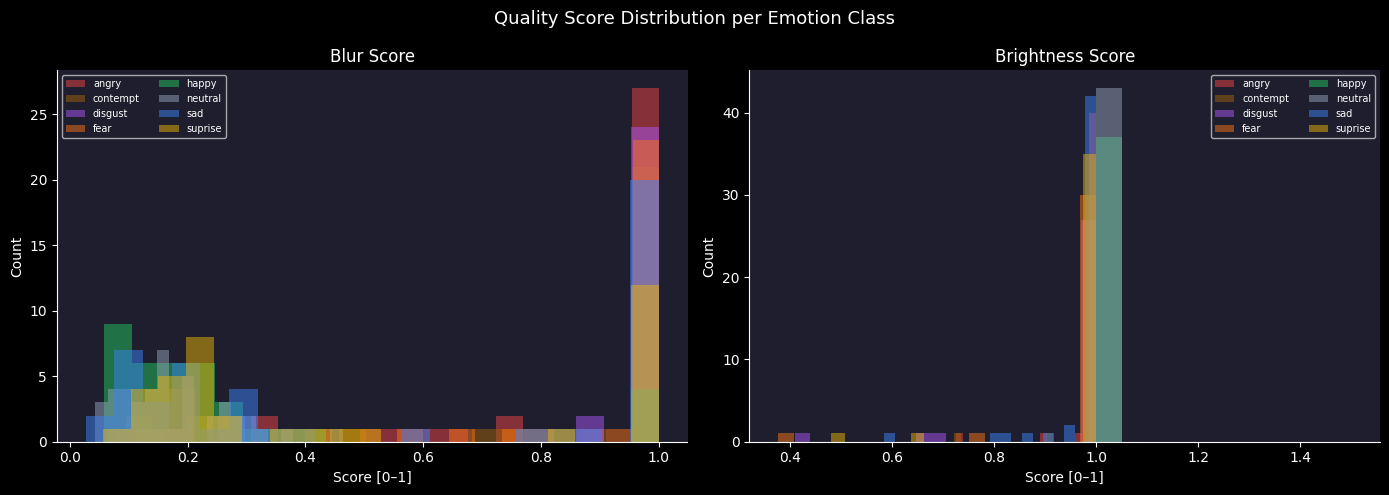

In [5]:
def compute_quality(img_bgr):
    """Hitung blur dan brightness score."""
    gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur  = min(1.0, cv2.Laplacian(gray, cv2.CV_64F).var() / 500.0)
    ycrcb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)
    lum   = float(ycrcb[:,:,0].mean())
    if lum < 20 or lum > 235:  bright = 0.0
    elif 60 <= lum <= 180:      bright = 1.0
    elif lum < 60:              bright = (lum-20)/40
    else:                       bright = (235-lum)/55
    return blur, bright

sample_n = min(300, len(train_df))
q_data   = {"emotion":[], "blur":[], "brightness":[]}

for _, row in train_df.sample(sample_n, random_state=0).iterrows():
    img = cv2.imread(row["path"])
    if img is None: continue
    b, br = compute_quality(img)
    q_data["emotion"].append(row["emotion"])
    q_data["blur"].append(b)
    q_data["brightness"].append(br)

q_df = pd.DataFrame(q_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Quality Score Distribution per Emotion Class", fontsize=13, color="white")
for ax, metric in zip(axes, ["blur","brightness"]):
    for emo, grp in q_df.groupby("emotion"):
        ax.hist(grp[metric], bins=20, alpha=0.5, label=emo,
                color=CMAP.get(emo,"#888"), edgecolor="none")
    ax.set_title(f"{metric.capitalize()} Score", color="white")
    ax.set_xlabel("Score [0–1]", color="white"); ax.set_ylabel("Count", color="white")
    ax.legend(fontsize=7, facecolor="#1e1e2e", labelcolor="white", ncol=2)
    ax.set_facecolor("#1e1e2e"); ax.tick_params(colors="white")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(SAVE_DIR/"preprocessing_03_quality.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

## 5. Buat Preprocessed Dataset (Semua Gambar)

⚠️ **Catatan:** Sel ini memproses SEMUA gambar ke `data/processed/`.
Training langsung menggunakan folder `dataset/` (tidak butuh `data/processed/`),
namun file ini berguna untuk pipeline offline augmentation (Notebook 03).

In [6]:
# Buat struktur output folder
for out_split in ["train","val","test"]:
    for emo in EMOTION_CLASSES:
        (OUTPUT_DIR/out_split/emo).mkdir(parents=True, exist_ok=True)

saved    = 0
skipped  = 0
clahe_cv = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

print(f"📦 Memproses {len(df):,} gambar ke {OUTPUT_DIR} ...")
print("   (resize 224×224 + CLAHE YCrCb equalization)")

for i, row in tqdm(df.iterrows(), total=len(df), desc="Preprocessing"):
    try:
        out_split = SPLITS_MAP.get(row["split"], "train")
        img = cv2.imread(row["path"])
        if img is None:
            skipped += 1; continue

        # Resize
        img_224 = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)

        # CLAHE di channel luminance (YCrCb)
        img_ycrcb = cv2.cvtColor(img_224, cv2.COLOR_BGR2YCrCb)
        img_ycrcb[:,:,0] = clahe_cv.apply(img_ycrcb[:,:,0])
        img_out   = cv2.cvtColor(img_ycrcb, cv2.COLOR_YCrCb2BGR)

        fname = Path(row["path"]).stem
        out_p = OUTPUT_DIR / out_split / row["emotion"] / f"{fname}.jpg"
        cv2.imwrite(str(out_p), img_out, [cv2.IMWRITE_JPEG_QUALITY, 95])
        saved += 1
    except Exception as e:
        skipped += 1
        print(f"   Error [{row['path']}]: {e}")

print(f"\n✅ Selesai! Saved: {saved:,} | Skipped: {skipped}")
print(f"   Output: {OUTPUT_DIR}")
print("\n➡️  Next: Notebook 03 — Augmentation & Imbalance Handling")

📦 Memproses 75,914 gambar ke D:\BIG-Data\tuber\data\processed ...
   (resize 224×224 + CLAHE YCrCb equalization)


Preprocessing: 100%|██████████| 75914/75914 [18:28<00:00, 68.46it/s] 


✅ Selesai! Saved: 75,914 | Skipped: 0
   Output: D:\BIG-Data\tuber\data\processed

➡️  Next: Notebook 03 — Augmentation & Imbalance Handling
